Then uploading my files in Python which feels easier, I've changed my runtime to R.

Reading my newly created and uploaded .csv of cleaned data, double checking to see if upload worked after changing runtime to R.

In [ ]:
df <- read.csv("cleaned_data.csv")
head(df)

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,⋯,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,has_complaint,has_incident,low_rating
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>,<int>,<int>
1,O00001,C0292,passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,⋯,South,Consumer,2025-03-02 11:24:00,73.2,57.9,App,Active,0,0,0
2,O00002,C0459,passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,⋯,WEST,Consumer,2024-09-23 21:00:00,56.1,62.6,App,Dormant,0,0,0
3,O00003,C0161,passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,⋯,north,Consumer,2024-06-07 22:41:00,87.1,36.6,App,Active,1,0,0
4,O00004,C0520,parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,⋯,NORTH,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active,0,0,0
5,O00005,C0558,retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,⋯,SOUTH,Consumer,2024-06-29 19:47:00,64.3,38.5,Phone,Active,1,0,0
6,O00006,C0437,retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,⋯,Airport,Consumer,2025-04-16 19:57:00,50.7,49.3,App,Active,0,0,0


Loading SQL packages for R

In [ ]:
install.packages("sqldf")
library(sqldf)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Now querying using SQL will start for deliver status distribution, complaints, average rating by hub, incidents vs delivery status, and route overrides impact.

Delivery Status Distribution

In [ ]:
sqldf("
SELECT delivery_status, COUNT(*) as count
FROM df
GROUP BY delivery_status
")

delivery_status,count
<chr>,<int>
,300
Delayed,202
Failed,132
OnTime,616


Complaints

In [ ]:
sqldf("
SELECT has_complaint, COUNT(*) as total_orders
FROM df
GROUP BY has_complaint
")

has_complaint,total_orders
<int>,<int>
0,965
1,285


Average Rating by Hub

In [ ]:
sqldf("
SELECT hub_id, AVG(customer_rating_post_delivery) as avg_rating
FROM df
GROUP BY hub_id
ORDER BY avg_rating DESC
")

hub_id,avg_rating
<chr>,<dbl>
H02,3.913679
H04,3.884646
H06,3.844808
H07,3.814348
H01,3.812353
H03,3.797647
H08,3.793516
H05,3.605739
,NA


Incidents vs Delivery Status

In [ ]:
sqldf("
SELECT delivery_status, AVG(has_incident) as incident_rate
FROM df
GROUP BY delivery_status
")

delivery_status,incident_rate
<chr>,<dbl>
,0.0000000
Delayed,0.2475248
Failed,0.2196970
OnTime,0.2743506


Route Overrides Impact

In [ ]:
sqldf("
SELECT delivery_status, AVG(has_incident) as incident_rate
FROM df
GROUP BY delivery_status
")

delivery_status,incident_rate
<chr>,<dbl>
,0.0000000
Delayed,0.2475248
Failed,0.2196970
OnTime,0.2743506


# Analysing and Visualisation

Adding library to visualise findings in R

In [ ]:
install.packages("ggplot2")
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Creating a delivery status count figure

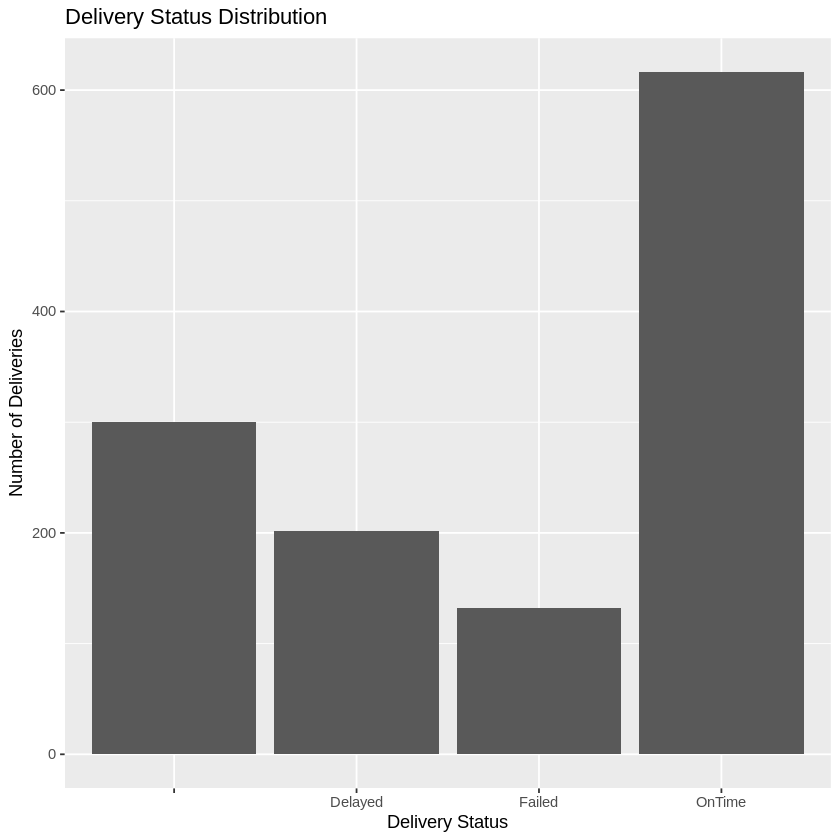

In [ ]:
ggplot(df, aes(x = delivery_status)) +
  geom_bar() +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Number of Deliveries"
  )

Creating a complaints comparison figure

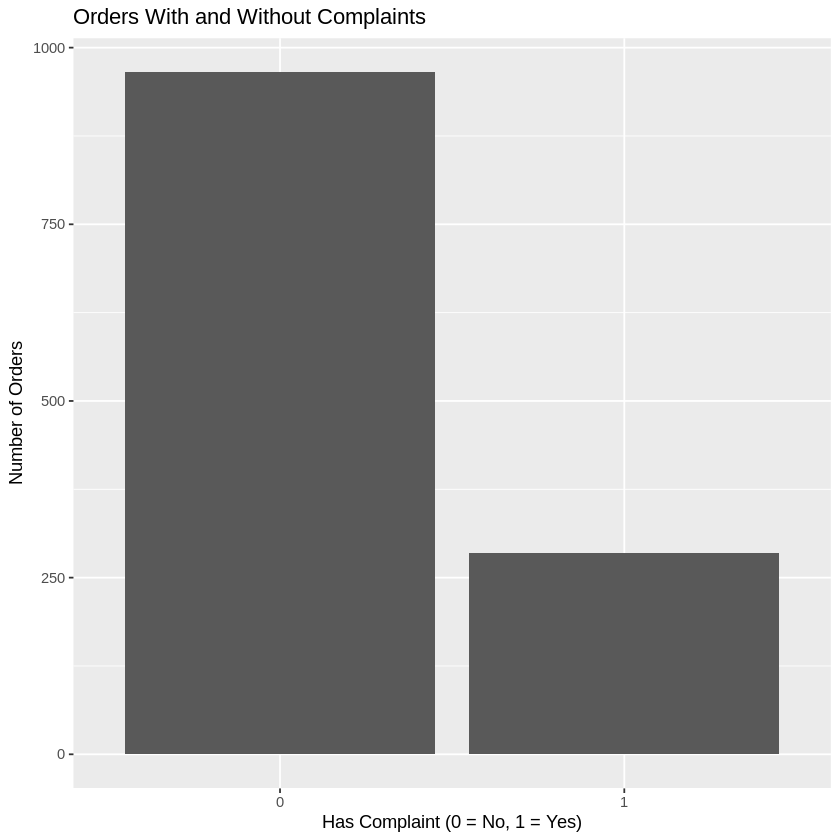

In [ ]:
ggplot(df, aes(x = factor(has_complaint))) +
  geom_bar() +
  labs(
    title = "Orders With and Without Complaints",
    x = "Has Complaint (0 = No, 1 = Yes)",
    y = "Number of Orders"
  )

Visualising the average rating by hub

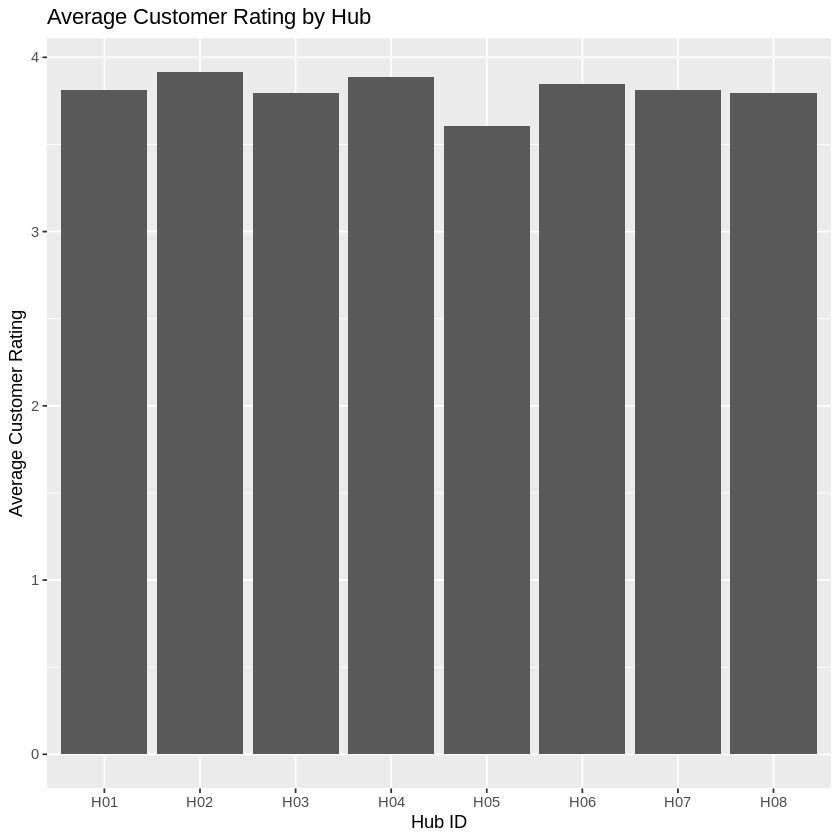

In [ ]:
hub_rating <- aggregate(customer_rating_post_delivery ~ hub_id, data = df, FUN = mean)

ggplot(hub_rating, aes(x = hub_id, y = customer_rating_post_delivery)) +
  geom_col() +
  labs(
    title = "Average Customer Rating by Hub",
    x = "Hub ID",
    y = "Average Customer Rating"
  )

Creating a visualisation for route overrides vs rating

Warning message:
“Removed 300 rows containing missing values or values outside the scale range
(`geom_point()`).”


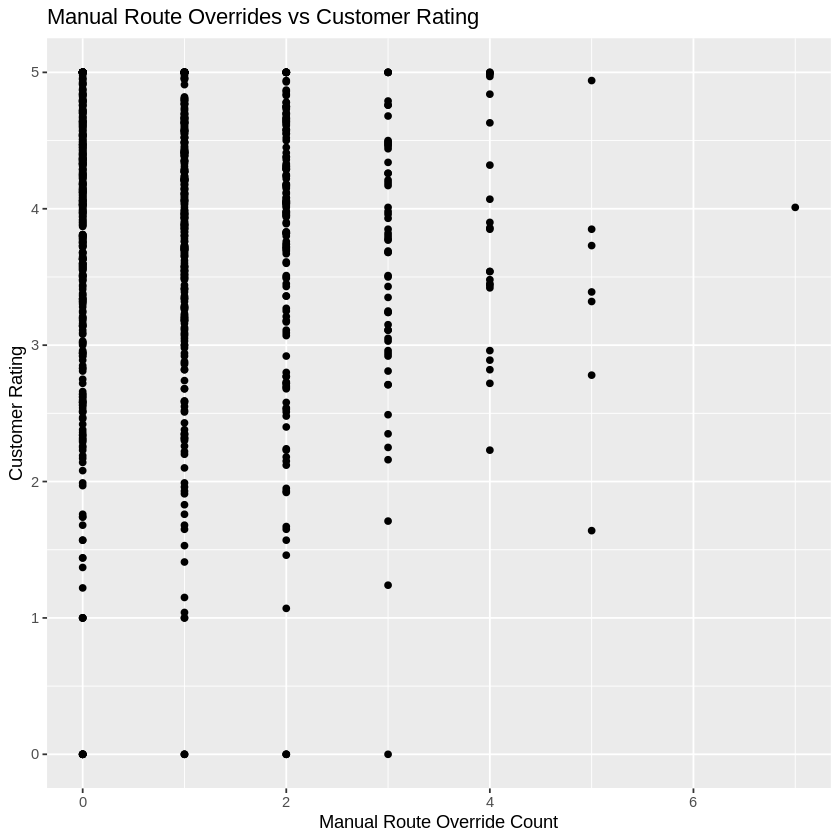

In [ ]:
ggplot(df, aes(x = manual_route_override_count, y = customer_rating_post_delivery)) +
  geom_point() +
  labs(
    title = "Manual Route Overrides vs Customer Rating",
    x = "Manual Route Override Count",
    y = "Customer Rating"
  )

Visualising the incident rate by delivery status

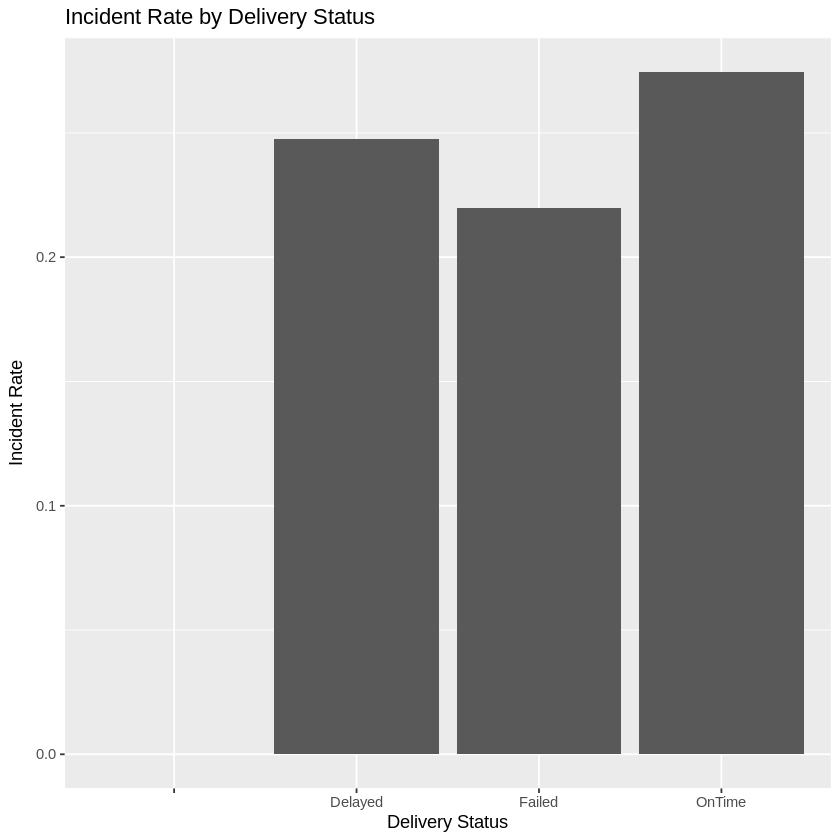

In [ ]:
incident_rate <- aggregate(has_incident ~ delivery_status, data = df, FUN = mean)

ggplot(incident_rate, aes(x = delivery_status, y = has_incident)) +
  geom_col() +
  labs(
    title = "Incident Rate by Delivery Status",
    x = "Delivery Status",
    y = "Incident Rate"
  )